# **Google Colab Notebook: Analysis of ML-Based Workload Prediction Studies**
### **Notebook Aims**
This notebook is designed to systematically analyze previous studies on cloud workload prediction using machine learning, as reviewed in existing surveys. Our goals are:

1. **Recreating and Extending Workload Prediction Study Tables**  
   - Reconstruct tables summarizing past studies based on available survey data.  
   - Extend the data to include research advancements up to 2025.  
   - Categorize studies based on methodologies, predicted factors, and datasets used.  

2. **Visualization and Statistical Analysis**  
   - Generate bar charts, stacked bar charts, and trend lines to illustrate study distributions.  
   - Show how different ML approaches (e.g., *Regression*, *Classification*, *Deep Learning*) have evolved over time.  
   - Display the number of studies published across different time intervals (2000-2025).  

3. **Insights on Research Trends and Workarounds**  
   - Identify key challenges in workload prediction and methodologies addressing them.  
   - Highlight the most frequently used datasets and metrics in studies.  
   - Provide recommendations on emerging research directions for 2025 and beyond.  

### **Dataset & Sources**
- Extracted from survey papers, specifically:

  1.   [*A Review on Machine Learning Methods for Workload Prediction in Cloud Computing*](https://ieeexplore.ieee.org/document/10326297) 2023
  2.   [*A review of machine learning in building load prediction*](https://www.sciencedirect.com/science/article/abs/pii/S0306261921000209) 2021
  3.   [*A survey and classification of the workload forecasting methods in cloud computing*](https://link.springer.com/article/10.1007/s10586-019-03010-3) 2020


- Mapped citations from Table I and extended based on referenced studies.
- Visualization and trend analysis derived from aggregated dataset.

---

> This notebook serves as a structured approach to understanding ML-based workload prediction trends and aims to assist researchers in identifying gaps and opportunities in this field.


In [23]:
#import libs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

#specify no max value for the column width
pd.set_option('display.max_colwidth', None)

Re-create *Table I. Comparison of ML-based workload prediction studies* in survey paper: *"A Review on Machine Learning Methods for Workload Prediction in Cloud Computing"*

In [6]:
# Reload and display the updated DataFrame
verified_df_no_duplicates = pd.read_csv("final_papers.csv")
verified_df_no_duplicates

,Ref,Method and Technique,Predicted Factor,Metric,Dataset,scheme,Paper Title,Published Year
0,[13],SVR,"CPU, Mem.",MAPE,Google,Regression,A hybrid heuristic-based tuned support vector regression model for cloud load prediction,2015
1,[14],SVR,"CPU, Mem.",MSE,RUBiS,Regression,Virtual machine migration triggering using application workload prediction,2015
2,[15],"LR, RR, ARDR, EN, GRU","CPU, Mem., BW, Disk",RMSE,Bitbrains,Regression,Workload forecasting and energy state estimation in cloud data centres: ML-centric approach,2022
3,[48],SVR,"CPU, Mem., Disk","MAE, MSE, MAPE, R2","Google, Bitbrains, PlanetLab",Regression,Predicting multi-attribute host resource utilization using support vector regression technique,2020
4,[4],NN,"CPU, Disk, Req.",MSE,"NASA, Saskatchewan",Classification,NN-based workload prediction model for cloud systems,2018
5,[5],GRU,CPU,MSE,"Google, Alibaba",Classification,GRU-based predictive analysis for cloud workload management,2019
6,[16],SVM,"CPU, Mem.","RMSE, MAE",Google,Classification,Load prediction using SVM in distributed environments,2016
7,[17],NN,"CPU, Disk",RMSE,Self-made,Classification,Hybrid approaches for cloud load forecasting,2017
8,[18],LSTM,CPU,MSE,PlanetLab,Deep Learning,Deep learning approaches for cloud workload prediction,2020
9,[19],DL,CPU,"MAPE, RMSE",PlanetLab,Deep Learning,Cloud resource allocation prediction using machine learning,2018


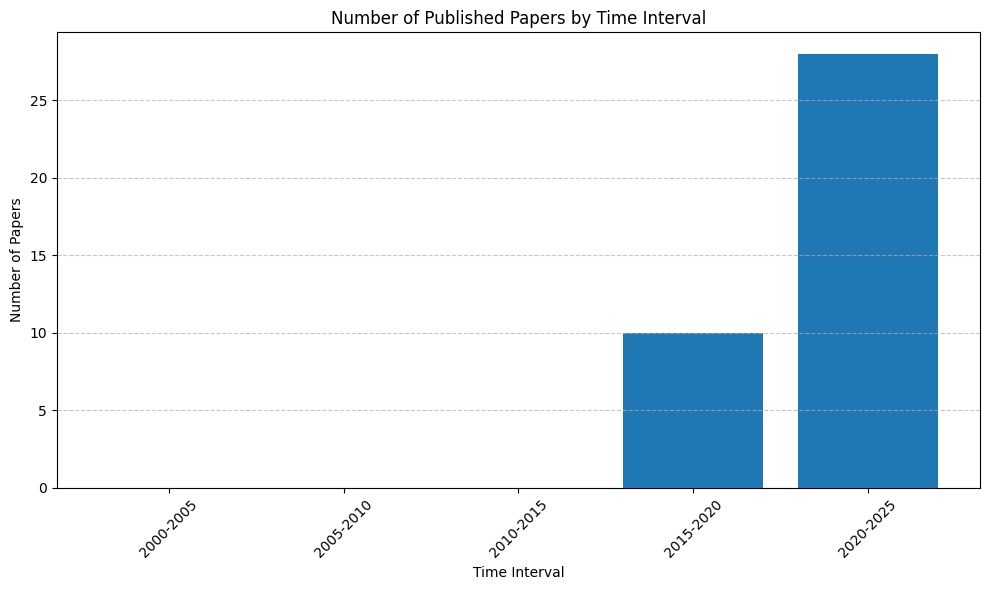

In [7]:
# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Define time intervals
bins = [2000, 2005, 2010, 2015, 2020, 2025]
labels = ['2000-2005', '2005-2010', '2010-2015', '2015-2020', '2020-2025']

# Ensure "Published Year" column exists and categorize into intervals
if 'Published Year' in uploaded_df.columns:
    uploaded_df['Interval'] = pd.cut(uploaded_df['Published Year'], bins=bins, labels=labels, right=False)

    # Count the number of papers in each interval
    interval_counts = uploaded_df['Interval'].value_counts().sort_index()

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(interval_counts.index.astype(str), interval_counts.values)
    plt.title('Number of Published Papers by Time Interval')
    plt.xlabel('Time Interval')
    plt.ylabel('Number of Papers')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Display the plot
    plt.show()
else:
    print("The 'Published Year' column is missing in the dataset.")


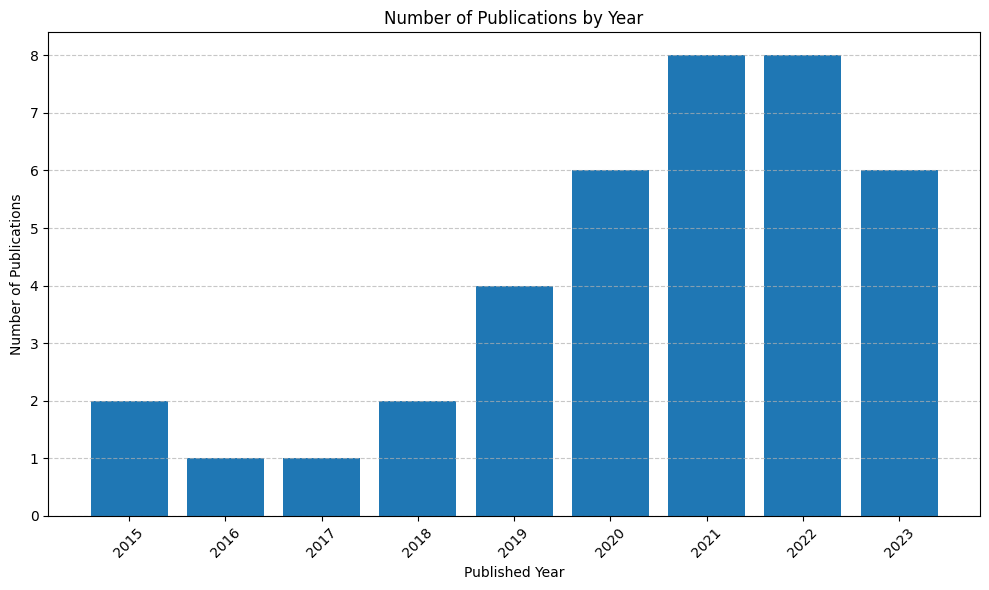

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(yearly_counts.index.astype(str), yearly_counts.values)
plt.title('Number of Publications by Year')
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


Maximum value: Published Year
2015    2
2016    1
2017    1
2018    2
2019    4
2020    6
2021    8
2022    8
2023    6
Name: count, dtype: int64
Maximum value: 8 at index: 2021


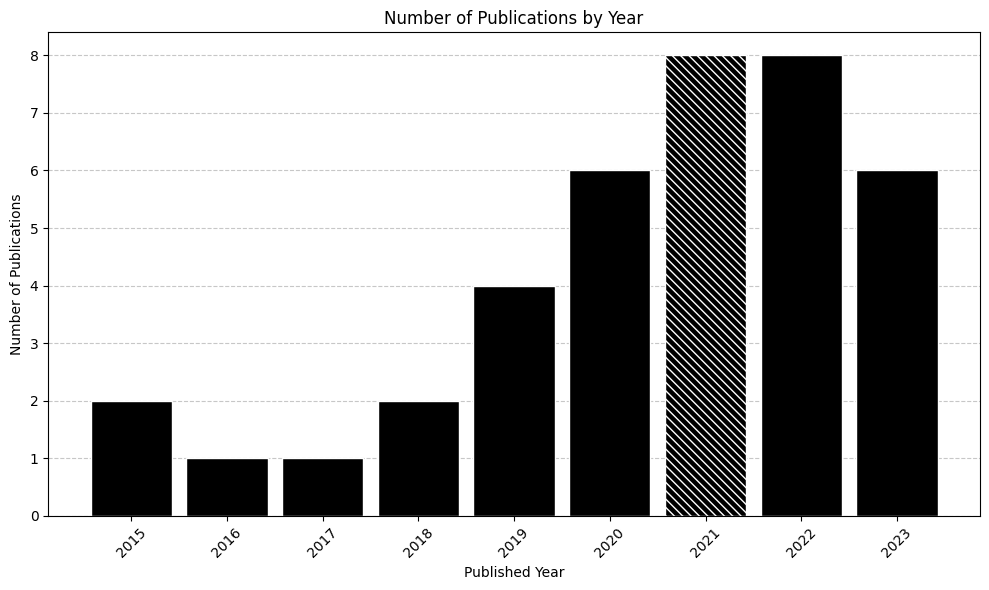

In [ ]:
# prompt: I want plot the above cell bar chart with hatched markers especifically those bars are maximum with different hatch. keep bar color black but with this setups: , zorder=2, width=0.85,
#               hatch=hatches, edgecolor="w" )

import matplotlib.pyplot as plt

# Assuming 'yearly_counts' is already defined from the previous code cell

# Find the maximum value and its index
max_value = yearly_counts.max()
print(f"Maximum value: {yearly_counts}")
max_index = yearly_counts.idxmax()
print(f"Maximum value: {max_value} at index: {max_index}")
# Create a list of hatches, with a different hatch for the maximum value
hatches = ['////' if year == max_index else '' for year in yearly_counts.index ]

# Plot the bar chart with hatches
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches, edgecolor="w")

# Set the hatch of the maximum bar differently
bars[yearly_counts.index.get_loc(max_index)].set_hatch('\\\\\\\\')

plt.title('Number of Publications by Year')
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

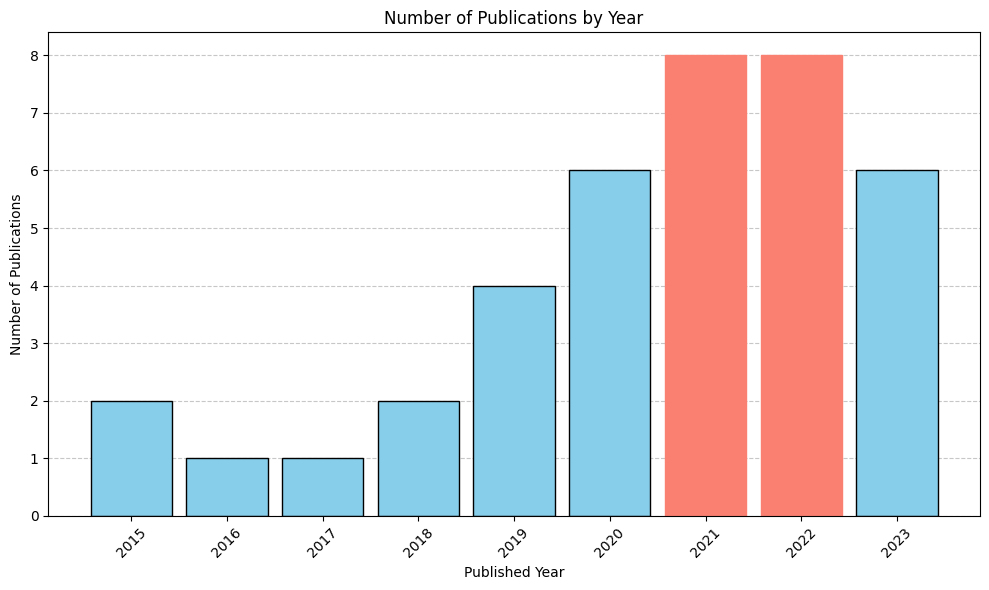

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Find years with maximum publications
max_value = yearly_counts.max()
max_years = yearly_counts[yearly_counts == max_value].index.tolist()

# Create hatches for bars
hatches = ['////' if year in max_years else '' for year in yearly_counts.index]


# Plot the bar chart with hatches for maximum values
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='skyblue', zorder=2, width=0.85, hatch=hatches, edgecolor="black")

#Highlight the maximum bars
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_color('salmon')


plt.title('Number of Publications by Year')
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

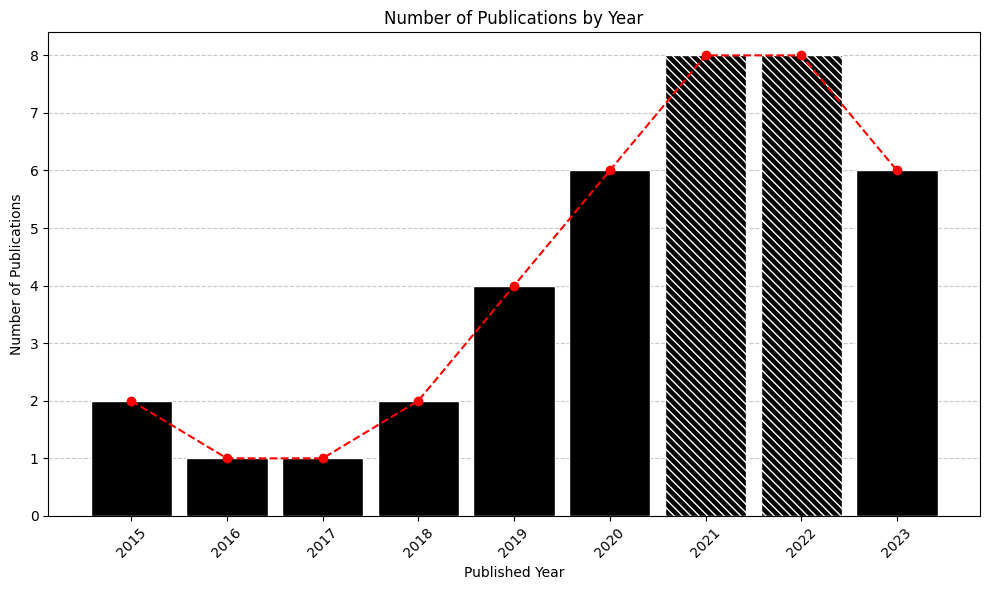

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Find years with maximum publications
max_value = yearly_counts.max()
max_years = yearly_counts[yearly_counts == max_value].index.tolist()

# Create hatches for bars
hatches = ['////' if year in max_years else '' for year in yearly_counts.index]


# Plot the bar chart with hatches for maximum values
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches, edgecolor="w")

#Highlight the maximum bars
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_hatch('\\\\\\\\')


# Calculate the total number of publications per year
total_publications_per_year = uploaded_df['Published Year'].value_counts().sort_index()

# Overlay the dashed line for the trend of total publications
plt.plot(
    total_publications_per_year.index.astype(str),
    total_publications_per_year.values,
    linestyle='--',
    color='red',
    marker='o',
    label='Total Publications'
)

plt.title('Number of Publications by Year')
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

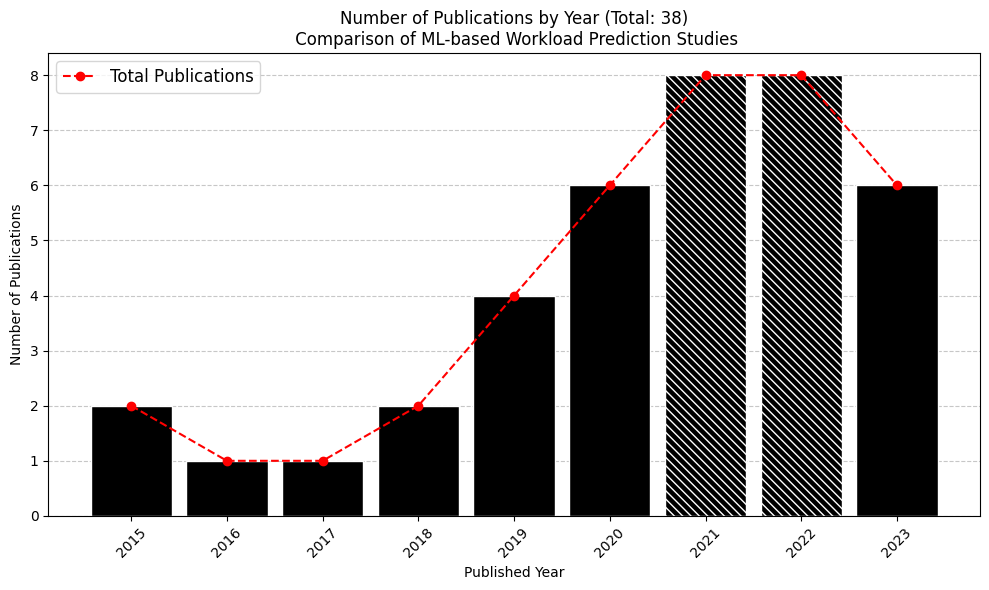

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Find years with maximum publications
max_value = yearly_counts.max()
max_years = yearly_counts[yearly_counts == max_value].index.tolist()

# Create hatches for bars
hatches = ['////' if year in max_years else '' for year in yearly_counts.index]

# Calculate the total number of publications
total_publications = len(uploaded_df)

# Plot the bar chart with hatches for maximum values
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches, edgecolor="w")

#Highlight the maximum bars
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_hatch('\\\\\\\\')


# Calculate the total number of publications per year
total_publications_per_year = uploaded_df['Published Year'].value_counts().sort_index()

# Overlay the dashed line for the trend of total publications
line, = plt.plot(
    total_publications_per_year.index.astype(str),
    total_publications_per_year.values,
    linestyle='--',
    color='red',
    marker='o',
    label='Total Publications' #Added label for legend
)

plt.title(f'Number of Publications by Year (Total: {total_publications})\n Comparison of ML-based Workload Prediction Studies') # Added total publications to the title
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add a legend with adjustable font size
font_size = 12  # Adjust font size as needed
plt.legend(handles=[line], fontsize=font_size)


# Display the plot
plt.show()

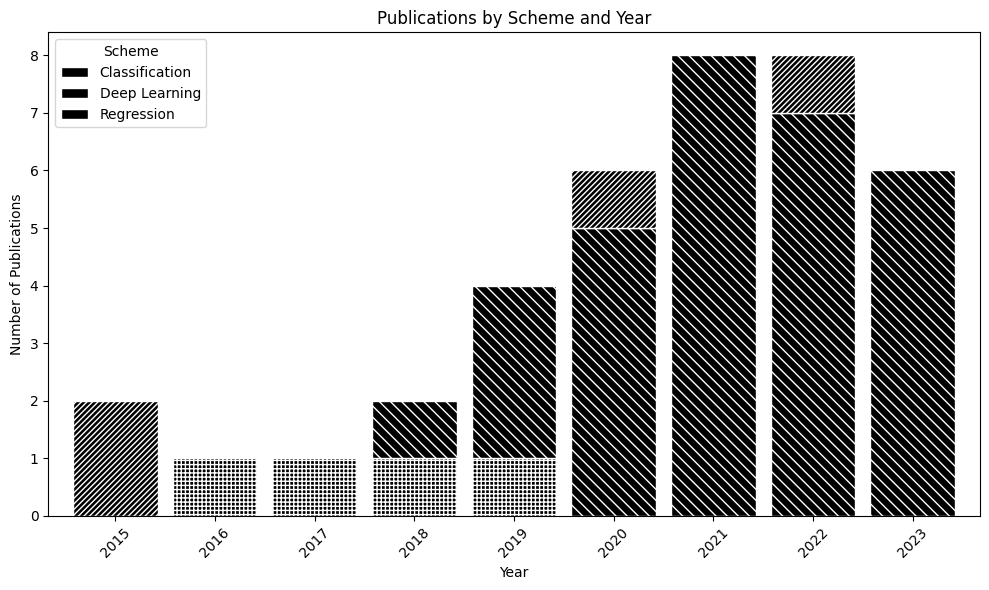

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe (assuming it's already loaded as 'uploaded_df')
# uploaded_df = pd.read_csv("/content/final_papers.csv")

# Create the pivot table
pivot_table = uploaded_df.pivot_table(index='Published Year', columns='scheme', aggfunc='size', fill_value=0)

# Define hatches for each scheme
hatches = {
    'Regression': '//////',
    'Deep Learning': '\\\\\\',
    'Classification': '++++'
}

# Plot the stacked bar chart
ax = pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color='black', width=0.85, edgecolor='w')

# Set hatches for each bar segment
for i, year in enumerate(pivot_table.index):
    bottom = 0
    for scheme in pivot_table.columns:
        height = pivot_table.loc[year, scheme]
        if height > 0:
            ax.bar(i, height, bottom=bottom, hatch=hatches[scheme], color='black', width=0.85, edgecolor='w', zorder=2)
        bottom += height

plt.title('Publications by Scheme and Year')
plt.xlabel('Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.legend(title='Scheme')
plt.tight_layout()
plt.show()

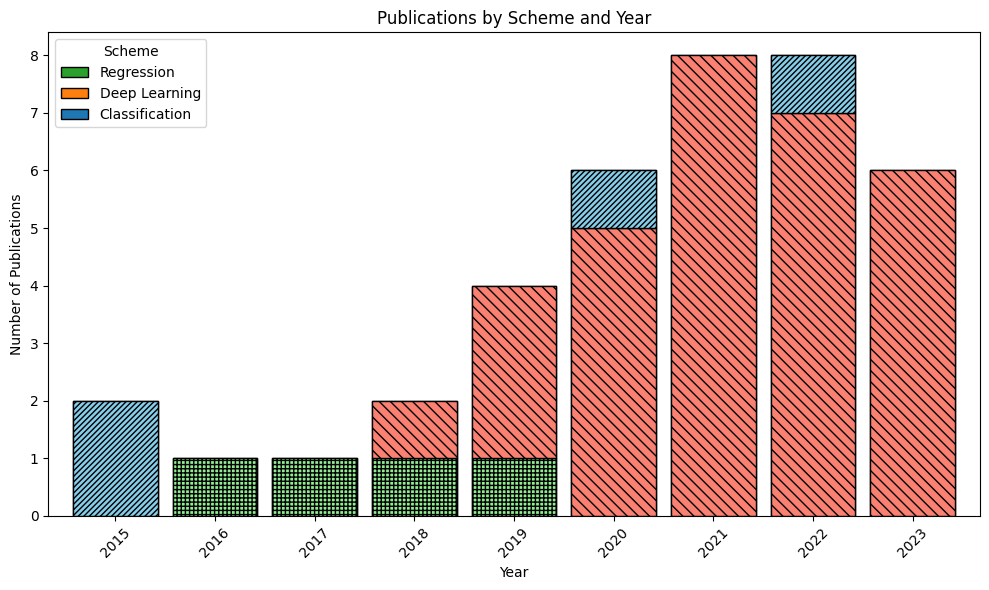

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe (assuming it's already loaded as 'uploaded_df')
# uploaded_df = pd.read_csv("/content/final_papers.csv")

# Create the pivot table
pivot_table = uploaded_df.pivot_table(index='Published Year', columns='scheme', aggfunc='size', fill_value=0)

# Define hatches and colors for each scheme
hatches = {
    'Regression': '//////',
    'Deep Learning': '\\\\\\',
    'Classification': '++++'
}
colors = {
    'Regression': 'skyblue',
    'Deep Learning': 'salmon',
    'Classification': 'lightgreen'
}

# Plot the stacked bar chart
ax = pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), width=0.85, edgecolor='black')

# Set hatches and colors for each bar segment
for i, year in enumerate(pivot_table.index):
    bottom = 0
    for scheme in pivot_table.columns:
        height = pivot_table.loc[year, scheme]
        if height > 0:
            ax.bar(i, height, bottom=bottom, hatch=hatches[scheme], color=colors[scheme], width=0.85, edgecolor='black', zorder=2)
        bottom += height

# Customize the plot
plt.title('Publications by Scheme and Year')
plt.xlabel('Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
# Sort legend labels to match the order in the 'hatches' dictionary
sorted_handles = [handles[labels.index(scheme)] for scheme in hatches]
sorted_labels = list(hatches.keys())

ax.legend(sorted_handles, sorted_labels, title='Scheme', loc='upper left') #Set legend position


plt.tight_layout()
plt.show()

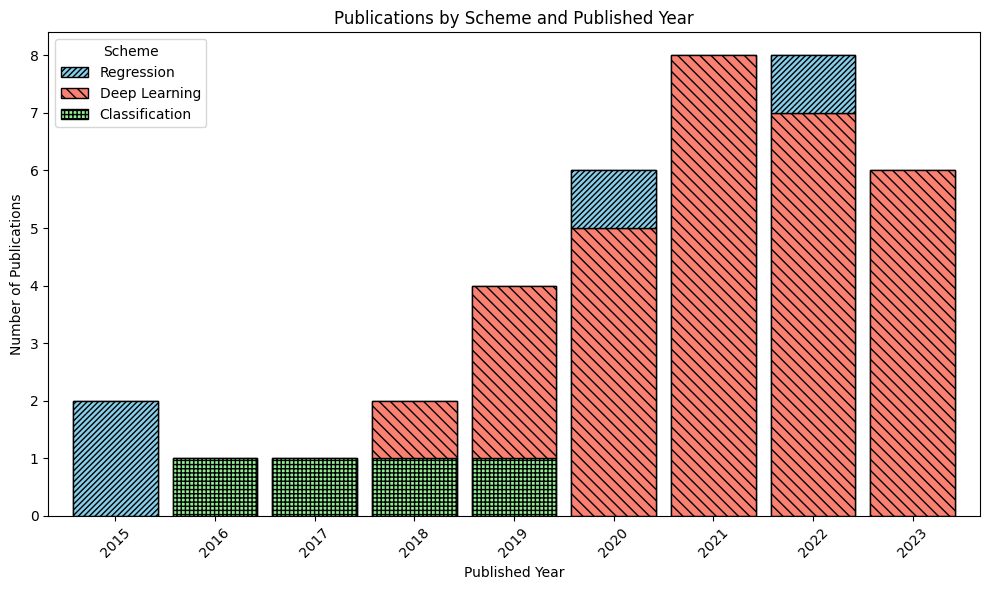

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe (assuming it's already loaded as 'uploaded_df')
# uploaded_df = pd.read_csv("/content/final_papers.csv")

# Create the pivot table
pivot_table = uploaded_df.pivot_table(index='Published Year', columns='scheme', aggfunc='size', fill_value=0)

# Define hatches and colors for each scheme
hatches = {
    'Regression': '//////',
    'Deep Learning': '\\\\\\',
    'Classification': '++++'
}
colors = {
    'Regression': 'skyblue',
    'Deep Learning': 'salmon',
    'Classification': 'lightgreen'
}

# Plot the stacked bar chart
ax = pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), width=0.85, edgecolor='black')

# Set hatches and colors for each bar segment
for i, year in enumerate(pivot_table.index):
    bottom = 0
    for scheme in pivot_table.columns:
        height = pivot_table.loc[year, scheme]
        if height > 0:
            ax.bar(i, height, bottom=bottom, hatch=hatches[scheme], color=colors[scheme], width=0.85, edgecolor='black', zorder=2)
        bottom += height

# Customize the plot
plt.title('Publications by Scheme and Published Year')
plt.xlabel('Published Year') #Corrected x-axis label
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)

# Improve legend
handles, labels = ax.get_legend_handles_labels()
# Sort legend labels to match the order in the 'hatches' dictionary
sorted_handles = [handles[labels.index(scheme)] for scheme in hatches]
sorted_labels = list(hatches.keys())

# Create custom legend with hatches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[scheme], edgecolor='black', hatch=hatches[scheme], label=scheme) for scheme in hatches]
ax.legend(handles=legend_elements, title='Scheme', loc='upper left')


plt.tight_layout()
plt.show()

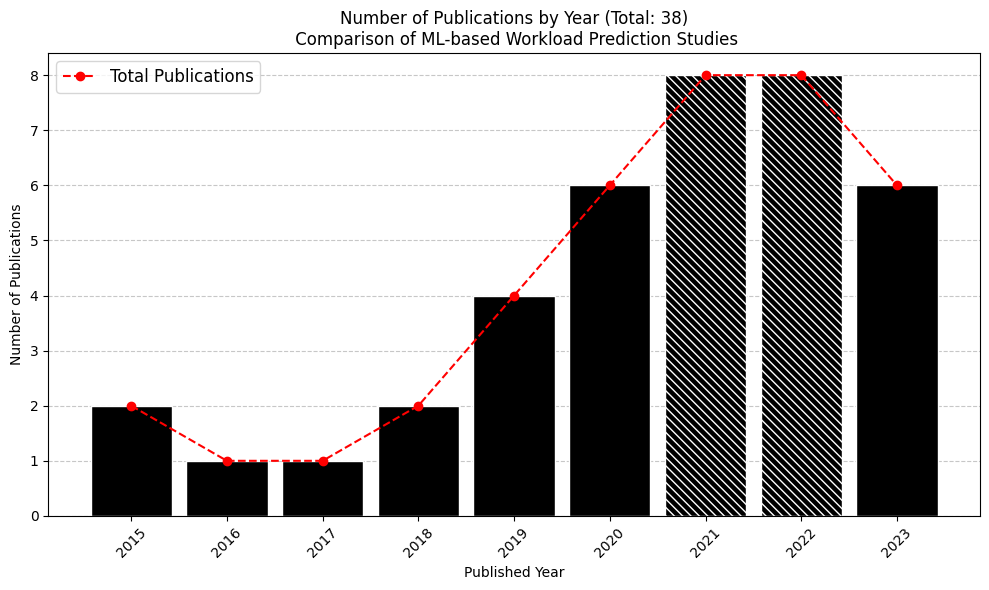

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Find years with maximum publications
max_value = yearly_counts.max()
max_years = yearly_counts[yearly_counts == max_value].index.tolist()

# Create hatches for bars
hatches = ['////' if year in max_years else '' for year in yearly_counts.index]

# Calculate the total number of publications
total_publications = len(uploaded_df)

# Plot the bar chart with hatches for maximum values
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches, edgecolor="w")

#Highlight the maximum bars
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_hatch('\\\\\\\\')


# Calculate the total number of publications per year
total_publications_per_year = uploaded_df['Published Year'].value_counts().sort_index()

# Overlay the dashed line for the trend of total publications
line, = plt.plot(
    total_publications_per_year.index.astype(str),
    total_publications_per_year.values,
    linestyle='--',
    color='red',
    marker='o',
    label='Total Publications' #Added label for legend
)

plt.title(f'Number of Publications by Year (Total: {total_publications})\n Comparison of ML-based Workload Prediction Studies') # Added total publications to the title
plt.xlabel('Published Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add a legend with adjustable font size
font_size = 12  # Adjust font size as needed
plt.legend(handles=[line], fontsize=font_size)


# Display the plot
plt.show()

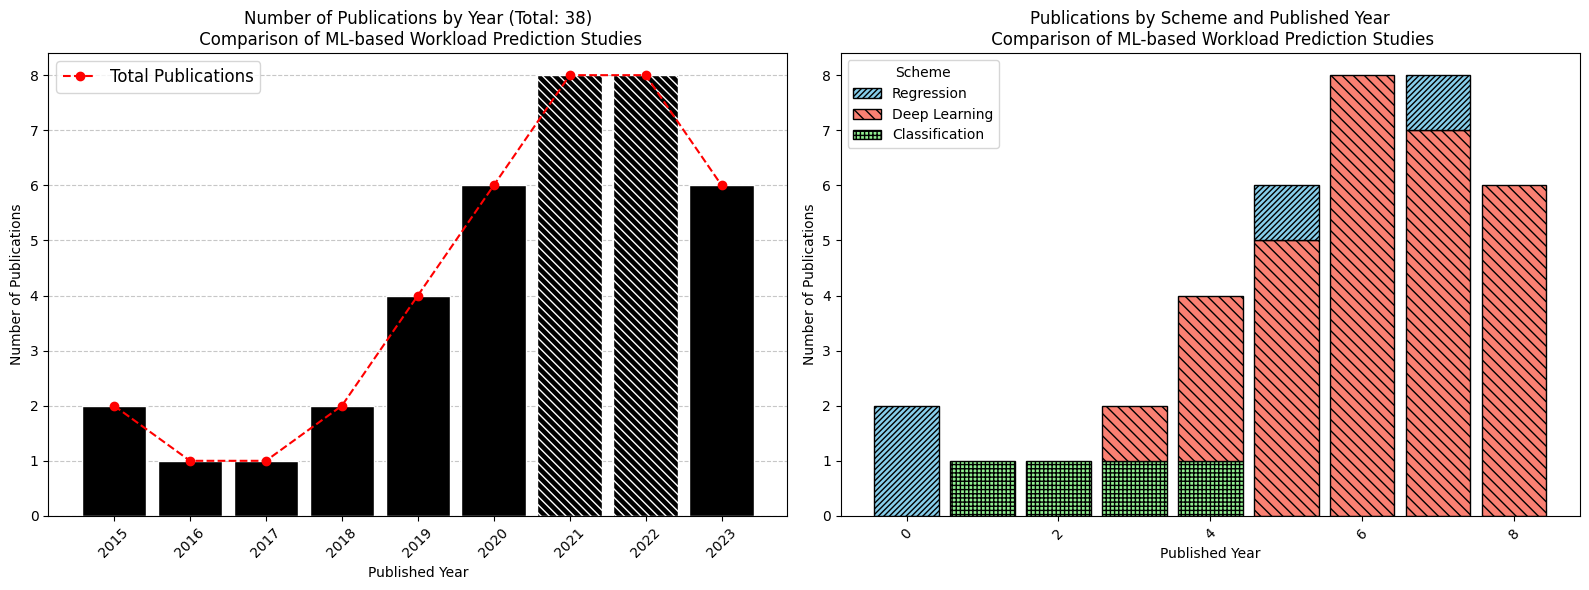

In [18]:
import matplotlib.pyplot as plt

# Assuming 'yearly_counts' and 'pivot_table' are defined from the previous code cells

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of Publications by Year
bars = axes[0].bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches, edgecolor="w")
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_hatch('\\\\\\\\')

line, = axes[0].plot(
    total_publications_per_year.index.astype(str),
    total_publications_per_year.values,
    linestyle='--',
    color='red',
    marker='o',
    label='Total Publications'
)
axes[0].set_title(f'Number of Publications by Year (Total: {total_publications})\n Comparison of ML-based Workload Prediction Studies')
axes[0].set_xlabel('Published Year')
axes[0].set_ylabel('Number of Publications')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(handles=[line], fontsize=12)

# Re-define hatches and colors dictionaries here:
hatches = {
    'Regression': '//////',
    'Deep Learning': '\\\\\\',
    'Classification': '++++'
}
colors = {
    'Regression': 'skyblue',
    'Deep Learning': 'salmon',
    'Classification': 'lightgreen'
}

# Plot 2: Publications by Scheme and Year
for i, year in enumerate(pivot_table.index):
    bottom = 0
    for scheme in pivot_table.columns:
        height = pivot_table.loc[year, scheme]
        if height > 0:
            # Use the hatches and colors dictionaries defined earlier
            axes[1].bar(i, height, bottom=bottom, hatch=hatches.get(scheme, ''), color=colors.get(scheme, 'black'),
                        width=0.85, edgecolor='black', zorder=2)
        bottom += height

axes[1].set_title('Publications by Scheme and Published Year\n Comparison of ML-based Workload Prediction Studies')
axes[1].set_xlabel('Published Year')
axes[1].set_ylabel('Number of Publications')
axes[1].tick_params(axis='x', rotation=45)



# Improve Legend: Create custom legend with hatches
legend_elements = [Patch(facecolor=colors[scheme], edgecolor='black', hatch=hatches[scheme], label=scheme)
                   for scheme in hatches]
axes[1].legend(handles=legend_elements, title='Scheme', loc='upper left')

plt.tight_layout()
plt.show()

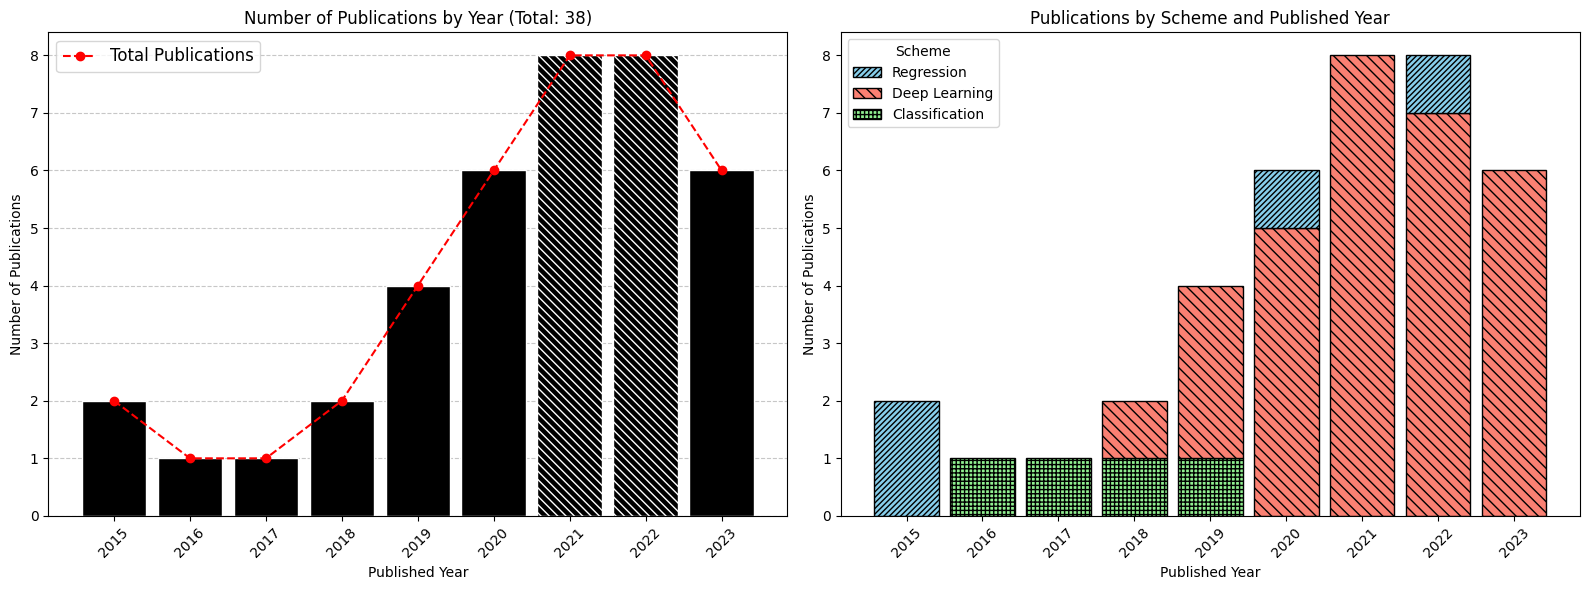

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Load the uploaded CSV file into a pandas DataFrame
uploaded_df = pd.read_csv("/content/final_papers.csv")

# Count the number of publications for each year
yearly_counts = uploaded_df['Published Year'].value_counts().sort_index()

# Find years with maximum publications
max_value = yearly_counts.max()
max_years = yearly_counts[yearly_counts == max_value].index.tolist()

# Create hatches for bars
# Instead of a dictionary, create a list of hatch styles for each year
hatches_list = ['' for _ in range(len(yearly_counts))]
for year in max_years:
    hatches_list[yearly_counts.index.get_loc(year)] = '////'

# Calculate the total number of publications
total_publications = len(uploaded_df)

# Calculate the total number of publications per year
total_publications_per_year = uploaded_df['Published Year'].value_counts().sort_index()


# Create the pivot table
pivot_table = uploaded_df.pivot_table(index='Published Year', columns='scheme', aggfunc='size', fill_value=0)

# Define hatches and colors for each scheme - Keep these for the second plot
hatches = {
    'Regression': '//////',
    'Deep Learning': '\\\\\\',
    'Classification': '++++'
}
colors = {
    'Regression': 'skyblue',
    'Deep Learning': 'salmon',
    'Classification': 'lightgreen'
}


# Assuming 'yearly_counts' and 'pivot_table' are defined from the previous code cells

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of Publications by Year
# Use the hatches_list instead of the hatches dictionary
bars = axes[0].bar(yearly_counts.index.astype(str), yearly_counts.values, color='black', zorder=2, width=0.85, hatch=hatches_list, edgecolor="w")
for year in max_years:
    bars[yearly_counts.index.get_loc(year)].set_hatch('\\\\\\\\')

line, = axes[0].plot(
    total_publications_per_year.index.astype(str),
    total_publications_per_year.values,
    linestyle='--',
    color='red',
    marker='o',
    label='Total Publications'
)
axes[0].set_title(f'Number of Publications by Year (Total: {total_publications})')
axes[0].set_xlabel('Published Year')
axes[0].set_ylabel('Number of Publications')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(handles=[line], fontsize=12)


# Plot 2: Publications by Scheme and Year
# Use the pivot_table index directly for the x-axis
x_values = pivot_table.index.astype(str)
for i, year in enumerate(pivot_table.index):
    bottom = 0
    for scheme in pivot_table.columns:
        height = pivot_table.loc[year, scheme]
        if height > 0:
            axes[1].bar(x_values[i], height, bottom=bottom, hatch=hatches.get(scheme, ''), color=colors.get(scheme, 'black'), width=0.85, edgecolor='black', zorder=2)
        bottom += height

axes[1].set_title('Publications by Scheme and Published Year')
axes[1].set_xlabel('Published Year') # Use 'Published Year' as the x-axis label
axes[1].set_ylabel('Number of Publications')
axes[1].tick_params(axis='x', rotation=45)

# Improve Legend: Create custom legend with hatches
legend_elements = [Patch(facecolor=colors[scheme], edgecolor='black', hatch=hatches[scheme], label=scheme)
                   for scheme in hatches]
axes[1].legend(handles=legend_elements, title='Scheme', loc='upper left')

plt.tight_layout()
plt.show()

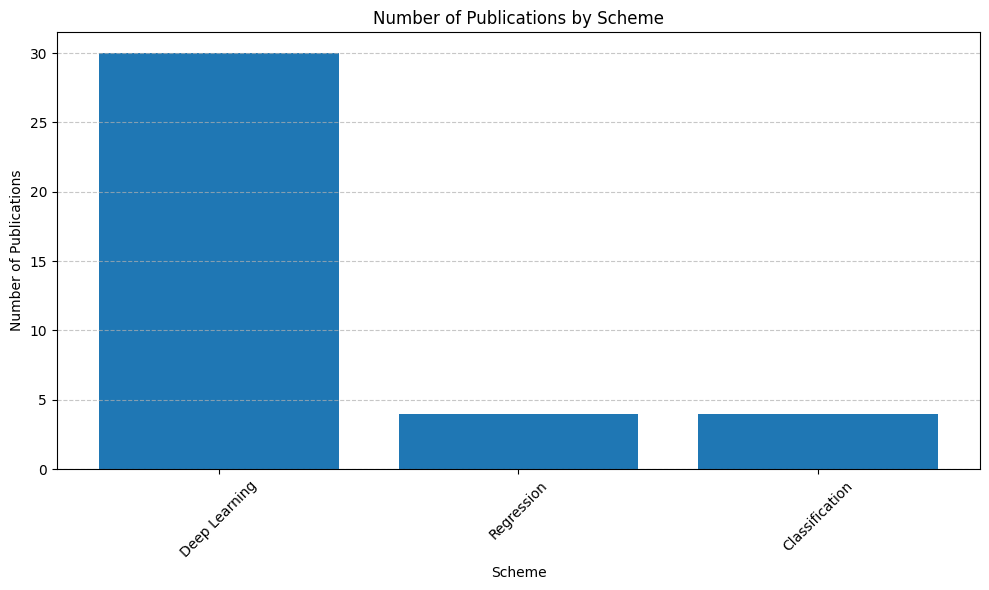

In [20]:
# Count the number of publications for each scheme
scheme_counts = uploaded_df['scheme'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(scheme_counts.index, scheme_counts.values)
plt.title('Number of Publications by Scheme')
plt.xlabel('Scheme')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()
